# Survival Analysis

**This notebook analyzes survival in patients with advanced urothelial cancer receiving first-line pembrolizumab versus those receiving carboplatin-based chemotherapy.** 

In [1]:
import numpy as np
import pandas as pd

from flatiron_cleaner import DataProcessorUrothelial

from iptw_survival import IPTWSurvivalEstimator

import matplotlib.pyplot as plt

## Process mortality data 

In [2]:
cohort = pd.read_csv('../outputs/full_cohort_carbo.csv')

In [3]:
cohort.sample(3)

,PatientID,LineName,StartDate
944,FC918D189BA92,Pembrolizumab,2019-09-17
3244,F03A84798396E,carboplatin,2015-08-13
47,FF4C22BEFE076,Pembrolizumab,2021-05-07


In [4]:
cohort.shape

(3712, 3)

In [5]:
processor = DataProcessorUrothelial()

# Process Enhanced_Mortality_V2.csv and use visit, telemedicine, biomarkers, oral, and progression data to determine censoring date 
mortality_df = processor.process_mortality(file_path = '../data/Enhanced_Mortality_V2.csv',
                                           index_date_df = cohort, 
                                           index_date_column = 'StartDate',
                                           visit_path = '../data/Visit.csv', 
                                           telemedicine_path = '../data/Telemedicine.csv', 
                                           biomarkers_path = '../data/Enhanced_AdvUrothelialBiomarkers.csv', 
                                           oral_path = '../data/Enhanced_AdvUrothelial_Orals.csv',
                                           progression_path = '../data/Enhanced_AdvUrothelial_Progression.csv',
                                           drop_dates = False)

2025-05-16 14:21:38,341 - INFO - Successfully read Enhanced_Mortality_V2.csv file with shape: (9040, 2) and unique PatientIDs: 9040
2025-05-16 14:21:38,350 - INFO - Successfully merged Enhanced_Mortality_V2.csv df with index_date_df resulting in shape: (3712, 3) and unique PatientIDs: 3712
2025-05-16 14:21:38,727 - INFO - The following columns ['last_visit_date', 'last_biomarker_date', 'last_oral_date', 'last_progression_date'] are used to calculate the last EHR date
2025-05-16 14:21:38,731 - INFO - Successfully processed Enhanced_Mortality_V2.csv file with final shape: (3712, 6) and unique PatientIDs: 3712. There are 0 out of 3712 patients with missing duration values


In [6]:
mortality_df.head(3)

,PatientID,imported_StartDate,DateOfDeath,event,last_ehr_activity,duration
0,F5AAF96C85477,2021-07-08,NaT,0,2021-09-14,68.0
1,F788831A66E9A,2023-02-22,NaT,0,2023-05-11,78.0
2,F6E944C1709E6,2020-08-12,2021-06-15,1,2021-06-15,307.0


In [7]:
mortality_df.shape

(3712, 6)

In [8]:
mortality_df = pd.merge(mortality_df, cohort[['PatientID', 'LineName']], on = 'PatientID', how = 'left')

In [9]:
mortality_df.shape

(3712, 7)

In [10]:
mortality_df.rename(columns={'imported_StartDate': 'StartDate'}, inplace=True)

In [11]:
mortality_df = mortality_df.query('duration >= 0')

In [12]:
mortality_df.shape

(3706, 7)

In [13]:
mortality_df = mortality_df.query('LineName == "Pembrolizumab" or LineName == "carboplatin"')

In [14]:
mortality_df['treatment'] = (mortality_df['LineName'] == 'Pembrolizumab').astype(int)

## Merge cleaned data from data_cleaning_trial_patients.ipynb

In [15]:
dtype_map = pd.read_csv('../outputs/final_df_dtypes.csv', index_col = 0).iloc[:, 0].to_dict()
df = pd.read_csv('../outputs/final_df.csv', dtype = dtype_map)

In [16]:
df.head(3)

,PatientID,DiseaseGrade,SmokingStatus,Surgery,GroupStage_mod,TStage_mod,NStage_mod,MStage_mod,SurgeryType_mod,days_diagnosis_to_adv,...,drug_abuse,psychoses,depression,van_walraven_score,lymph_met,thoracic_met,liver_met,bone_met,other_gi_met,other_combined_met
0,F0016E985D839,High grade (G2/G3/G4),1,1,IV,T3,N1,M0,upper,0.0,...,0,0,0,4,0,0,0,0,0,0
1,F001E5D4C6FA0,Low grade (G1),1,1,unknown,T1,unknown,unknown,bladder,274.0,...,0,0,0,<NA>,0,0,0,0,0,0
2,F0025BA658AE1,High grade (G2/G3/G4),1,0,unknown,T3,unknown,M0,NaN,621.0,...,0,0,0,4,0,0,0,0,0,0


In [17]:
df.shape

(6461, 149)

In [18]:
df = pd.merge(mortality_df[['PatientID' , 'event', 'duration', 'treatment']], df, on = 'PatientID', how = 'left')

In [19]:
df.shape

(3706, 152)

## Merge insurance and SES information from insurance_ses.ipynb

In [20]:
insurance_ses_df = pd.read_csv('../outputs/insurance_ses_df.csv')

In [21]:
insurance_ses_df.head(3)

,PatientID,commercial,medicaid,medicare,other_insurance,ses_mod
0,F5AAF96C85477,0,0,1,0,1 - Lowest SES
1,F788831A66E9A,1,0,1,0,1 - Lowest SES
2,F75847DF35E43,1,0,0,1,2-4


In [22]:
insurance_ses_df.shape

(6461, 6)

In [23]:
insurance_ses_df['ses_mod'] = insurance_ses_df['ses_mod'].astype('category')

In [24]:
df = pd.merge(df, insurance_ses_df, on = 'PatientID', how = 'left')

In [25]:
df.shape

(3706, 157)

## Survival Analysis 

### Preprocessing

In [26]:
(
    df.groupby('treatment')['event']
    .apply(lambda x: (x == 0).mean())
)

treatment
0    0.253375
1    0.332884
Name: event, dtype: float64

In [27]:
#df['creatinine_2'] = np.where(df['creatinine'] > 2, 1, 0)

In [28]:
df.groupby(['adv_diagnosis_year', 'treatment']).size().unstack(fill_value=0)

/var/folders/lr/vkkcj_s12115sxc05ly3mshh0000gn/T/ipykernel_42120/868052135.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['adv_diagnosis_year', 'treatment']).size().unstack(fill_value=0)


treatment,0,1
adv_diagnosis_year,,
2011,120,1
2012,165,2
2013,186,2
2014,198,2
2015,251,7
2016,243,19
2017,180,134
2018,135,213
2019,157,268


In [29]:
df['adv_diagnosis_year'] = df['adv_diagnosis_year'].astype(int)

In [30]:
df['before_2020'] = np.where(df['adv_diagnosis_year'] < 2020, 1, 0)

### IPTW 

In [31]:
estimator = IPTWSurvivalEstimator()

In [32]:
# We apply stabilized IPTW and clip propensity scores to the [0.01, 0.99] range to reduce the influence of extreme values
estimator.fit(df = df,
              treatment_col = 'treatment',
              cat_var = ['GroupStage_mod', 'ecog_index', 'ses_mod', 'PDL1_status'],
              cont_var = ['days_diagnosis_to_adv', 'age', 'weight_index', 'percent_change_weight', 'albumin', 'total_bilirubin', 'creatinine', 'van_walraven_score'],
              binary_var = ['Surgery', 'opioid', 'commercial', 'medicaid', 'before_2020'],
              lr_kwargs = {
                  'class_weight': 'balanced',
                  'solver': 'lbfgs',
                  'penalty': 'l2',
                  'max_iter': 1000,
                  'random_state': 42
              },
              clip_bounds = (0.01, 0.99),
              stabilized = True,)

In [33]:
iptw_df = estimator.transform()

In [34]:
ps_fig = estimator.propensity_score_plot(bins = 30)

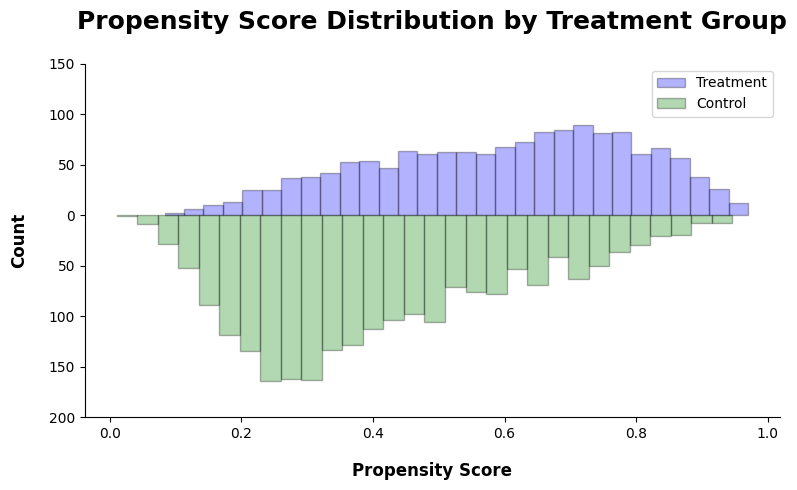

In [35]:
ps_fig

In [36]:
smd_df, smd_fig = estimator.standardized_mean_differences(return_fig = True)

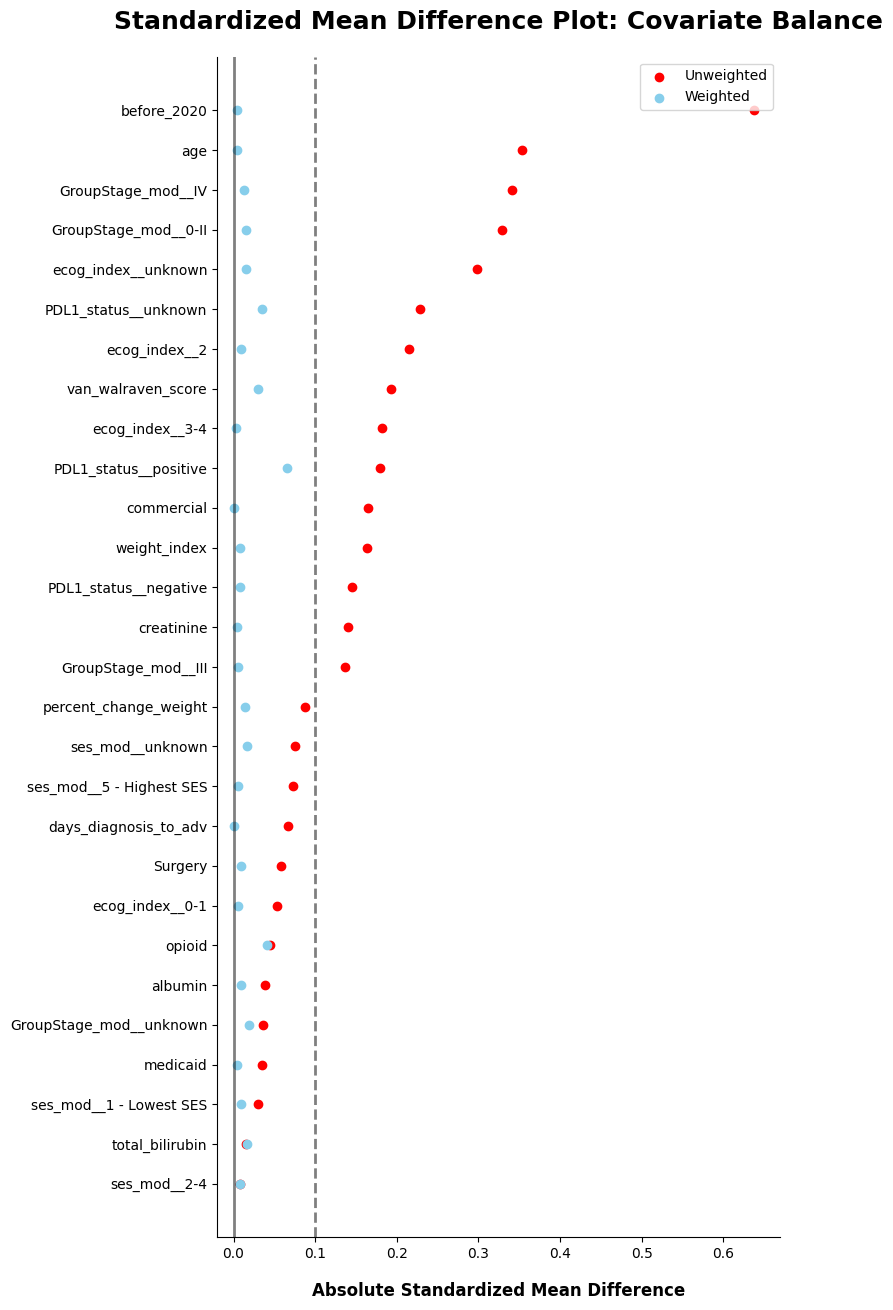

In [37]:
smd_fig

In [38]:
# Convert days to month
iptw_df['duration'] = iptw_df['duration']/30

In [39]:
km_confidence_intervals_df = estimator.km_confidence_intervals(df = iptw_df,
                                                               duration_col = 'duration',
                                                               event_col = 'event',
                                                               weight_col = 'iptw',
                                                               n_bootstrap = 1000,
                                                               random_state = 42)

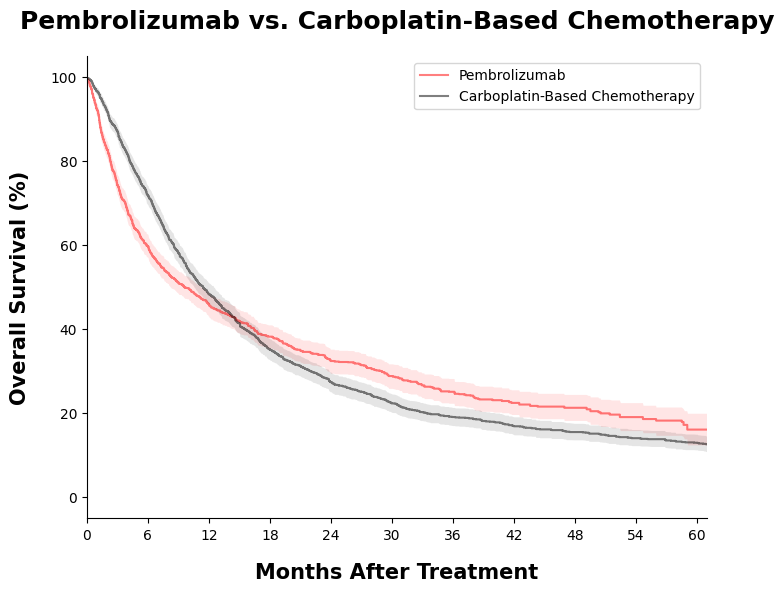

In [47]:
fig = plt.figure(figsize=(8, 6))

# Pembrolizumab arm
# Estimate
plt.step(km_confidence_intervals_df.time, 
         km_confidence_intervals_df.treatment_estimate * 100, 
         color = 'red', 
         alpha = 0.5,
         label = 'Pembrolizumab')

# 95% CI
plt.fill_between(km_confidence_intervals_df.time, 
                 km_confidence_intervals_df.treatment_lower_ci * 100, 
                 km_confidence_intervals_df.treatment_upper_ci * 100, 
                 facecolor = 'red', 
                 alpha = 0.1)

# Chemotherapy arm
# Estimate
plt.step(km_confidence_intervals_df.time, 
         km_confidence_intervals_df.control_estimate * 100, 
         color = 'black', 
         alpha = 0.5,
         label = 'Carboplatin-Based Chemotherapy')

# 95% CI
plt.fill_between(km_confidence_intervals_df.time, 
                 km_confidence_intervals_df.control_lower_ci * 100, 
                 km_confidence_intervals_df.control_upper_ci * 100, 
                 facecolor = 'black', 
                 alpha = 0.1)

plt.xticks(np.arange(0, 61, 6))
plt.xlim(0, 61)

plt.title('Pembrolizumab vs. Carboplatin-Based Chemotherapy', size = 18, weight = 'bold',  pad = 20)
plt.ylabel('Overall Survival (%)', size = 15, weight = 'bold', labelpad = 15)
plt.xlabel('Months After Treatment', size = 15, weight = 'bold', labelpad = 15)
plt.legend(prop = {'size': 10})

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.savefig('../outputs/survival_pembro_carbo.pdf', format = 'pdf', bbox_inches = 'tight')

In [41]:
results = estimator.survival_metrics(df = iptw_df,
                                     duration_col = 'duration',
                                     event_col = 'event',
                                     weight_col = 'iptw',
                                     psurv_time_points = [36, 48],
                                     rmst_time_points = [36, 48],
                                     median_time = True,
                                     n_bootstrap = 1000,
                                     random_state = 42)

In [42]:
# Median results
print('Median Survival Results')
print(f'Pembrolizumab: {tuple(round(x, 1) for x in results['treatment']['median'])} months')
print(f'Chemotherapy: {tuple(round(x, 1) for x in results['control']['median'])} months')
print(f'Difference: {tuple(round(x, 1) for x in results['difference']['median'])} months')

Median Survival Results
Pembrolizumab: (9.7, 8.3, 11.3) months
Chemotherapy: (11.5, 10.6, 12.5) months
Difference: (-1.8, -3.5, 0.2) months


In [43]:
# RMST results at 3 years
print('RMST Results at 3 Years')
print(f'Pembrolizumab: {tuple(round(x, 1) for x in results['treatment']['rmst'][36])} months')
print(f'Chemotherapy: {tuple(round(x, 1) for x in results['control']['rmst'][36])} months')
print(f'Difference: {tuple(round(x, 1) for x in results['difference']['rmst'][36])} months')

# RMST results at 4 years
print('')
print('RMST Results at 4 Years')
print(f'Pembrolizumab: {tuple(round(x, 1) for x in results['treatment']['rmst'][48])} months')
print(f'Chemotherapy: {tuple(round(x, 1) for x in results['control']['rmst'][48])} months')
print(f'Difference: {tuple(round(x, 1) for x in results['difference']['rmst'][48])} months')

RMST Results at 3 Years
Pembrolizumab: (15.9, 15.0, 16.7) months
Chemotherapy: (15.9, 15.2, 16.5) months
Difference: (-0.0, -1.0, 1.1) months

RMST Results at 4 Years
Pembrolizumab: (18.6, 17.5, 19.7) months
Chemotherapy: (17.9, 17.1, 18.8) months
Difference: (0.6, -0.7, 2.0) months


In [44]:
# Probability of survival at 3 years
print('Probability of Survival at 3 Years')
print(f'Pembrolizumab: {tuple(round(x, 3) for x in results['treatment']['survival_prob'][36])}')
print(f'Chemotherapy: {tuple(round(x, 3) for x in results['control']['survival_prob'][36])}')
print(f'Difference: {tuple(round(x, 3) for x in results['difference']['survival_prob'][36])}')

# Probability of survival at 4 years
print('')
print('Probability of Survival at 4 Years')
print(f'Pembrolizumab: {tuple(round(x, 3) for x in results['treatment']['survival_prob'][48])}')
print(f'Chemotherapy: {tuple(round(x, 3) for x in results['control']['survival_prob'][48])}')
print(f'Difference: {tuple(round(x, 3) for x in results['difference']['survival_prob'][48])}')

Probability of Survival at 3 Years
Pembrolizumab: (0.252, 0.223, 0.282)
Chemotherapy: (0.191, 0.17, 0.213)
Difference: (0.06, 0.024, 0.098)

Probability of Survival at 4 Years
Pembrolizumab: (0.213, 0.182, 0.244)
Chemotherapy: (0.156, 0.136, 0.175)
Difference: (0.058, 0.023, 0.094)
